# Decision Tree From Scratch

## 1. Modelando DecisionTree com NumPy

In [2]:
from collections import Counter
import numpy as np


class Node:
    def __init__(
        self,
        feature=None,
        threshold=None,
        samples=0,
        left=None,
        right=None,
        *,
        value=None,
    ):
        self.feature = feature
        self.threshold = threshold
        self.samples = samples
        self.left = left
        self.right = right
        self.value = value

    def is_leaf_node(self):
        return self.value is not None


class DecisionTree:
    def __init__(self, min_sample_split=2, max_depth=100, n_features=None):
        self.min_samples_split = min_sample_split
        self.max_depth = max_depth
        self.n_features = n_features
        self.root = None

    def fit(self, X, y):
        # primeiro verifica se o n_features não é maior que o numero de features real
        self.n_features = (
            X.shape[1] if not self.n_features else min(X.shape[1], self.n_features)
        )
        self.root = self._grow_tree(X, y)
        return self

    # helper function
    def _grow_tree(self, X, y, depth=0):
        self.n_samples, self.n_feats = X.shape
        self.n_labes = len(np.unique(y))

        # adicionando critérios de parada
        if (
            depth >= self.max_depth
            or self.n_labes == 1
            or self.n_samples < self.min_samples_split
        ):
            # calcula o value retornado
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)

        # selecionando as features aleatórias por n_features
        feat_idxs = np.random.choice(self.n_feats, self.n_features, replace=False)

        # decidindo o split
        best_threshold, best_feature_idx = self._best_split(X, y, feat_idxs)

        # criando child nodes
        left_idxs, right_idxs = self._split(X[:, best_feature_idx], best_threshold)
        left = self._grow_tree(X[left_idxs, :], y[left_idxs], depth + 1)
        right = self._grow_tree(X[right_idxs, :], y[right_idxs], depth + 1)
        return Node(
            feature=best_feature_idx, threshold=best_threshold, left=left, right=right
        )

    def _best_split(self, X, y, feat_idxs):
        best_gini = float("inf")
        split_idx, split_threshold = None, None

        for feat_idx in feat_idxs:
            X_column = X[:, feat_idx]
            thresholds = np.unique(X_column)

            for thr in thresholds:
                gini = self._get_gini(X_column, y, thr)

                if gini < best_gini:
                    best_gini = gini
                    split_idx = feat_idx
                    split_threshold = thr

        return split_threshold, split_idx

    def _get_gini(self, X_column, y, thr):
        # 1. Dividir as amostras utilizando o threshold informado
        left_idxs, right_idxs = self._split(X_column, thr)

        # 2. Verificar se a divisão é válida
        #    (nenhum dos lados pode ficar vazio)
        if len(left_idxs) == 0 or len(right_idxs) == 0:
            return float("inf")

        # 3. Obter os rótulos (y) do filho esquerdo
        y_left, y_right = [y[idx] for idx in left_idxs], [y[idx] for idx in right_idxs]

        # 5. Calcular o índice de Gini do filho esquerdo/direito
        left_gini, left_total = self._calculate_gini(y_left)
        right_gini, right_total = self._calculate_gini(y_right)

        # 6. Calcular a média ponderada dos dois ginis
        #    utilizando o número de amostras em cada filho
        gini_mean = self._calculate_weight_gini(
            left_gini, left_total, right_gini, right_total
        )

        # 7. Retornar o Gini da divisão
        return gini_mean

    def _split(self, X_column, thr):

        left_idxs, right_idxs = [], []
        for idx, ft in enumerate(X_column):
            if ft <= thr:
                left_idxs.append(idx)
            else:
                right_idxs.append(idx)

        return left_idxs, right_idxs

    def _calculate_gini(self, y):
        frequency = Counter(y)
        # keys -> valores
        # values -> frequencias
        gini = 1
        total = sum(frequency.values())
        for _, value in frequency.items():
            gini -= (value / total) ** 2

        return gini, total

    def _calculate_weight_gini(self, left_gini, left_total, right_gini, right_total):

        total = left_total + right_total
        mean_gini = left_gini * (left_total / total) + right_gini * (
            right_total / total
        )

        return mean_gini

    def _most_common_label(self, y):
        counter = Counter(y)
        value = counter.most_common(1)[0][0]
        return value

    def predict(self, X):
        return np.array([self._predict_instance(instance) for instance in X])

    def _predict_instance(self, instance):
        node = self.root

        while not node.is_leaf_node():
            if instance[node.feature] <= node.threshold:
                node = node.left
            else:
                node = node.right
        return node.value


## 2. Modelando com Scikit-Learn e From Scratch

In [3]:
from sklearn.tree import DecisionTreeClassifier

#modelo do sklearn
sk_tree_clf = DecisionTreeClassifier()

#modelo com numpy
scratch_tree_clf = DecisionTree()

## 3. Carregando dados e Treinando os modelos

In [8]:
from src.data_loading import load_data

X_train, X_test, y_train, y_test = load_data()

'''Treinando os modelos para comparar'''
sk_tree_clf.fit(X_train, y_train)
scratch_tree_clf.fit(X_train, y_train)

y_pred_sk = sk_tree_clf.predict(X_test)
y_pred_scratch = scratch_tree_clf.predict(X_test)

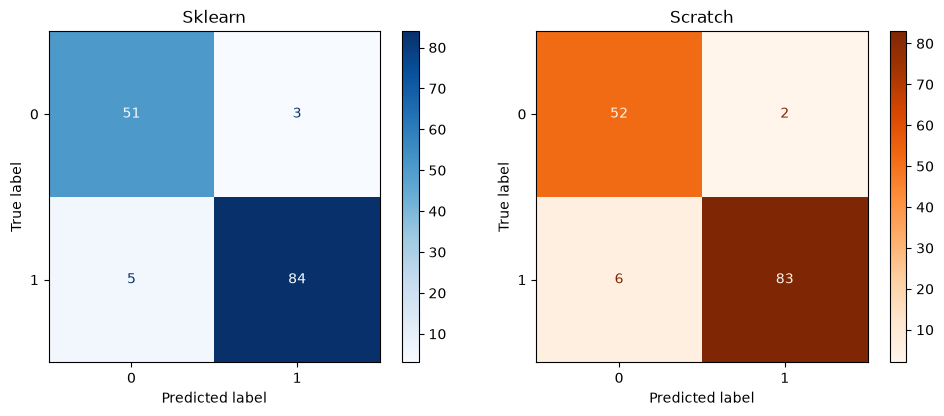

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix


cm_sk = confusion_matrix(y_test, sk_tree_clf.predict(X_test))
cm_scratch = confusion_matrix(y_test, scratch_tree_clf.predict(X_test))


fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay(cm_sk).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Sklearn')

ConfusionMatrixDisplay(cm_scratch).plot(ax=axes[1], cmap='Oranges')
axes[1].set_title('Scratch')

plt.tight_layout()
plt.show()

## 4. Visualizando a diferença de acurrácia

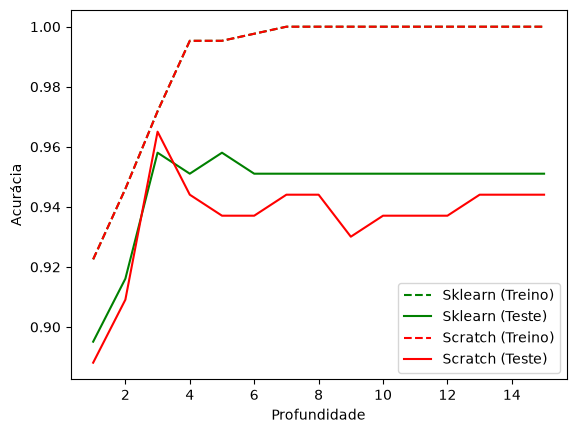

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

depths = range(1, 16)
sk_train, sk_test = [], []
sc_train, sc_test = [], []

for d in depths:
    # Sklearn
    sk = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train, y_train)
    sk_train.append(sk.score(X_train, y_train))
    sk_test.append(sk.score(X_test, y_test))
    
    # Scratch
    sc = DecisionTree(max_depth=d)
    sc.fit(X_train, y_train)
    sc_train.append(accuracy_score(y_train, sc.predict(X_train)))
    sc_test.append(accuracy_score(y_test, sc.predict(X_test)))

plt.plot(depths, sk_train, 'g--', label='Sklearn (Treino)')
plt.plot(depths, sk_test, 'g-', label='Sklearn (Teste)')
plt.plot(depths, sc_train, 'r--', label='Scratch (Treino)')
plt.plot(depths, sc_test, 'r-', label='Scratch (Teste)')

plt.xlabel('Profundidade')
plt.ylabel('Acurácia')
plt.legend()
plt.show()